<b>Example follows example from Géron, A. (2022). Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow (3rd ed.). O’Reilly Media.</b>

## Clustering
The goal of clusetring is to identify similar instances and assig them to clusters, or groups of similar instances based on theor shared characteristics. 

Clustering approach is used across data analysis, customer segmentation, recommender systems, search engines, image segmentation, semi-supervised learning, dimensionality reduction, and more. 

Note: 
K-means does not behave very well when the clusters have varying sizes, different densities, or nonspherical shapes (different dimensions, densities, and orientations). It is important to scale the input features before running k-means, or the clusters may be very stretched and k-means will perform poorly. Scaling the features does not guarantee that all the clusters will be nice and spherical, but it generally helps k-means.





## K-means (lables or centroids given)
- Centroid -  Assign and label all instances baased on the cluster whose centroid is closest 
- Labels - locate each cluster’s centroid by computing the mean of the instances in that cluster

In [1]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [2]:
# Creating artificial data where we already know which cluster each observation belongs to
# X = features 
# y = true clusters generated by make_blobs()

X, y = make_blobs(n_samples=1000, centers=5, random_state=42)

k = 5

kmeans = KMeans(n_clusters=k, random_state=42)  

y_pred = kmeans.fit_predict(X)    #y_pred = clusters discovered by K-Means, K-Means only sees X and has to discover the groups itsel

In [3]:
kmeans.cluster_centers_

array([[-6.68630691, -6.81139455],
       [ 2.03639615,  4.26762858],
       [-2.50265159,  9.03963769],
       [-8.80798056,  7.40425704],
       [ 4.66534309,  1.87476184]])

In [4]:
# Assign new instances to the cluster whose centroid is closest

import numpy as np
X_new = np.array ([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([1, 4, 1, 1], dtype=int32)

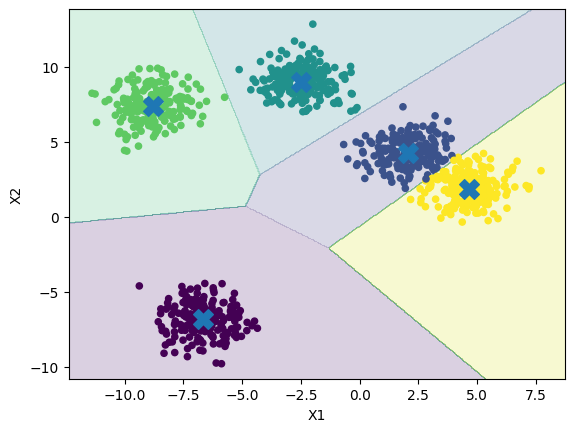

In [5]:
# Visualise Voronoi tessellation
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=5, random_state=42)
y_pred = kmeans.fit_predict(X)

# Create a grid covering the data

x1 = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 500)
x2 = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 500)
xx, yy = np.meshgrid(x1, x2)

# Predict the cluster for every point in the grid
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the Voronoi regions
plt.contourf(xx, yy, Z, alpha=0.2)

# Plot observations
plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=20)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker='X',
    s=200)

plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

k-means may struggle with blobls with different diameters. Its main focus lies on assigning the points to its closest centroid (hard clustering). Let's try to use soft clusetring, where the distance is measured between each instance and the cendtroid.

In [6]:
# transfrom fucntion measure the distance from each instance to every centroid
kmeans.transform(X_new).round(2)

array([[11.06,  3.05,  7.47, 10.33,  4.67],
       [13.09,  2.46,  8.94, 12.99,  1.67],
       [10.48,  5.19,  6.06,  7.29,  7.75],
       [10.01,  5.34,  6.56,  7.6 ,  7.69]])

X_new is located at a distance of 11.06 from the first centrodi, 3.05 from the second centrod etc..

## K-means (no lables, no centroids)
1. Placing the centroids randomly by picking k instances at random from the dataset and using their locations as centroids.
2. Label the instances, update the centroids, and repeat the step again until the centroids stop moving and it coverges.

Note: Although the algorithm is guaranteed to converge, it may not converge to the right solution (i.e., it may converge to a local optimum): whether it does or not depends on the centroid initialization.

### Mitigation: Centroid initialization methods

In [7]:
good_init = np.array([[-3, 3], [-3, 2], [-3, 1], [-1, 2], [0, 2]])
kmeans = KMeans(n_clusters=5, init=good_init, random_state=42)
kmeans.fit(X)

,n_clusters,5
,init,"array([[-3, ... [ 0, 2]])"
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


### Finding the optimal number of clusters

**Intertia**: 
Lower inetria is always preffered as it indicates that the observations are closer to their centroids. However, the inertia is not a good performance metric when trying to choose k because it keeps getting lower as we increase k. 

k = 2 → high inertia
k = 3 → lower
k = 4 → even lower

And that’s also why I cannot simply select the k with the lowest inertia — k=10 will naturally tend to have lower inertia than k=3.

In [8]:
kmeans.inertia_

2986.675754535726

**Silhouette score** (The mean silhouette coefficient); more precise (but also more computationally expensive)m ranges between [-1 and +1].

* Coefficient close to +1: the instance is well inside its own cluster and far from other clusters
* Coefficient close to 0: it is close to a cluster boundary
* Coefficient close to –1: the instance may have been assigned to the wrong cluster.

Higher is better. And this is why it was useful in your earlier clustering work when your elbow was ambiguous between 3 and 4: the silhouette score gives you another piece of evidence for choosing k.

In [9]:
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X)

score = silhouette_score(X, kmeans.labels_)
print(f"Silhouette score: {score:.3f}")

Silhouette score: 0.678


In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_values = range(2, 11)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42)

    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

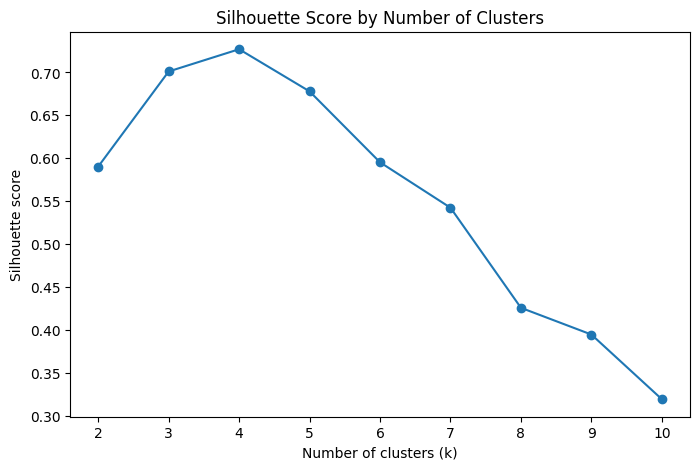

In [11]:
# Plotting
plt.figure(figsize=(8, 5))

plt.plot(k_values,
    silhouette_scores,
    marker='o')

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title('Silhouette Score by Number of Clusters')
plt.show()


### Image segmentation is the task of partitioning an image into multiple segments. 
There are several variants:

* In color segmentation, pixels with a similar color get assigned to the same segment. This is sufficient in many applications. For example, if you want to analyze satellite images to measure how much total forest area there is in a region, color segmentation may be just fine.

* In semantic segmentation, all pixels that are part of the same object type get assigned to the same segment. For example, in a self-driving car’s vision system, all pixels that are part of a pedestrian’s image might be assigned to the “pedestrian” segment (there would be one segment containing all the pedestrians).

* In instance segmentation, all pixels that are part of the same individual object are assigned to the same segment. In this case there would be a different segment for each pedestrian.

In [13]:
# PIL open and converts it into something Python/NumPy can work with
from PIL import Image 
import numpy as np
image = np.asarray(Image.open("data/ladybug.png"))

print(image.shape)

(208, 301, 4)


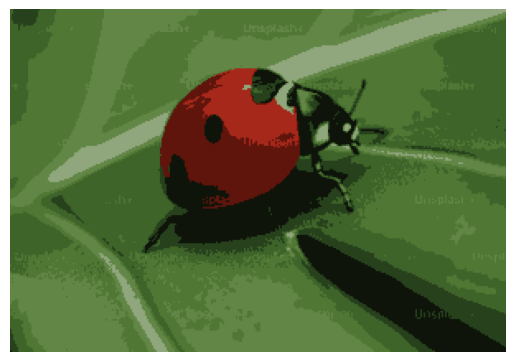

In [ ]:
# Remove alpha channel
image_rgb = image[:, :, :3]

# Flatten image into pixels × RGB
X = image_rgb.reshape(-1, 3)

# K-Means
kmeans = KMeans(n_clusters=8, random_state=42).fit(X)

# Replace pixels with cluster centroid colours
segmented_img = kmeans.cluster_centers_[kmeans.labels_]

# Reshape back to RGB image dimensions
segmented_img = segmented_img.reshape(image_rgb.shape)

# Convert back to uint8 which is valid 0–255 RGB image
segmented_img = segmented_img.astype(np.uint8)

# Display
plt.imshow(segmented_img)
plt.axis('off')
plt.show()

### Clustering for Semi-Supervised Learning
unlabeled instances and very few labeled instances. we are lokinmg at visual digit example.

1. Start with many unlabeled digit images
2. K-Means creates 50 clusters
3. Select one representative image from each cluster → 50 representative digits
4. Manually label only those 50 images
5. Train Logistic Regression using those representative labelled examples.

Instead of randomly labelling many observations, clustering helps select a small set of representative observations to label.

In [ ]:
#Load and split the dataset
from sklearn.datasets import load_digits

X_digits, y_digits = load_digits(return_X_y=True)
X_train, y_train = X_digits[:1400], y_digits[:1400]
X_test, y_test = X_digits[1400:], y_digits[1400:]

In [ ]:
#Basleine perfoirmance. Train a logistic regression model on these 50 labeled instances:
from sklearn.linear_model import LogisticRegression

n_labeled = 10
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [ ]:
# Perfomance score
log_reg.score(X_test, y_test)

0.5340050377833753

Model accuracy trained on the full data set is rather low, so let's see if we can get better results by clustering the training set first. For each cluster we will find the clostest centroid.

In [ ]:
#Cluster the training set into 10 clusters and find the image closest to the centroid
k = 10
kmeans = KMeans(n_clusters=k, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train)
representative_digit_idx = X_digits_dist.argmin(axis=0)
X_representative_digits = X_train[representative_digit_idx]

In [ ]:
X_representative_digits.shape

(10, 64)

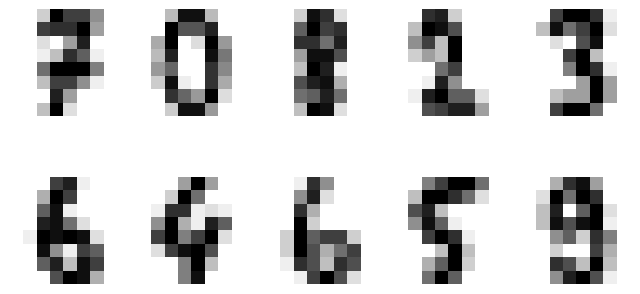

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 5, figsize=(8, 4))

for image, ax in zip(X_representative_digits, axes.ravel()):
    ax.imshow(image.reshape(8, 8), cmap="binary")
    ax.axis("off")

plt.show()

In [ ]:
# Each image is manually labelled. 
y_representative_digits = np.array([7, 0, 8, 2, 3, 6, 4, 6, 5, 9])

In [ ]:
#Checking if performance improved after clustering
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_representative_digits, y_representative_digits)
log_reg.score(X_test, y_test)

0.6926952141057935

Model Accuracy has improved from 53% to 70%

In [ ]:
#label propagation to all the other instances in the same cluster
y_train_propagated = np.empty(len(X_train), dtype=np.int64)
for i in range(k):
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

In [ ]:
#Train model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train_propagated)
log_reg.score(X_test, y_test)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.7355163727959698

In [ ]:
percentile_closest = 50

X_cluster_dist = X_digits_dist[np.arange(len(X_train)), kmeans.labels_]
for i in range(k):
    in_cluster = (kmeans.labels_ == i)
    cluster_dist = X_cluster_dist[in_cluster]
    cutoff_distance = np.percentile(cluster_dist, percentile_closest)
    above_cutoff = (X_cluster_dist > cutoff_distance)
    X_cluster_dist[in_cluster & above_cutoff] = -1

partially_propagated = (X_cluster_dist != -1)
X_train_partially_propagated = X_train[partially_propagated]
y_train_partially_propagated = y_train_propagated[partially_propagated]


In [ ]:
#Train model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train_propagated)
log_reg.score(X_test, y_test)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.7355163727959698

### DBSCAN
* “Tell me how many clusters you want, and I’ll assign every observation to one.” That works well for compact, roughly spherical groups. 

* Find areas where observations are densely packed together.

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [ ]:
# 1. Create sample data
X, y = make_moons(
    n_samples=500,
    noise=0.05,
    random_state=42
)

In [ ]:
# Scaling matters because DBSCAN determines whether observations are close together using distance.
# 2. Scale the features
X_scaled = StandardScaler().fit_transform(X)

In [ ]:
# 3. Fit DBSCAN

dbscan = DBSCAN(
    eps=0.3,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

- eps - determines the radius of that neighbourhood
- model asks which other observations are within 0.3 distance of this observation?
- Are there at least 5 observations in this neighbourhood?

* Core instances — enough neighbours exist within eps. These form the dense heart of a cluster.

* Non-core/border instances — close enough to a core instance to belong to its cluster, but don’t themselves have enough neighbours to be core instances.

* Anomalies/noise — don’t belong to a sufficiently dense region.

-1 → noise
 0 → cluster 0
 1 → cluster 1

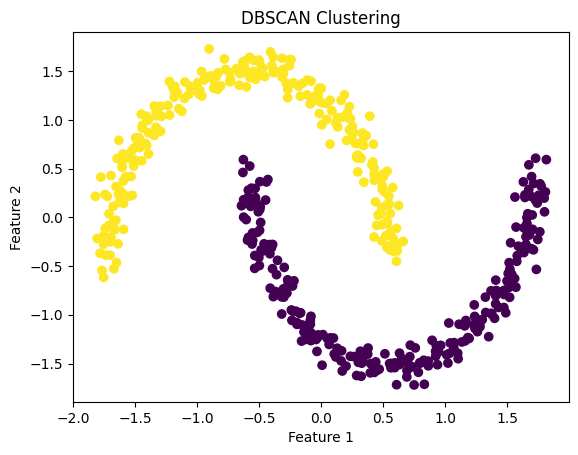

In [ ]:
# 4. Visualise the clusters

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=dbscan_labels
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering")
plt.show()

In [ ]:
print(X_scaled.shape)

print(dbscan_labels.shape)

(500, 2)
(500,)


In [ ]:
# Core instances
dbscan.core_sample_indices_[:10]

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
# Core features
dbscan.components_[:5]

array([[ 0.37512461, -1.40367864],
       [ 0.22681458,  1.13562771],
       [ 0.59544154, -1.49371022],
       [-0.94491835,  1.40974769],
       [-0.24311512,  1.61806199]])

In [ ]:
dbscan_small = DBSCAN(
    eps=0.10,
    min_samples=5
)

labels_small = dbscan_small.fit_predict(X_scaled)

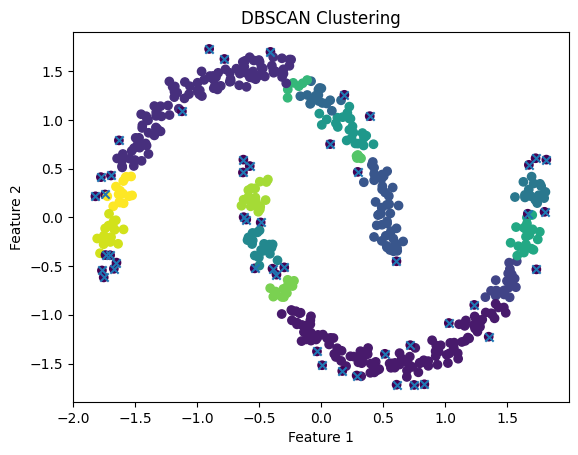

In [ ]:
# Clustered points
mask = labels_small != -1

# Visualise the clusters
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels_small
)

# Noise points
plt.scatter(
    X_scaled[~mask, 0],
    X_scaled[~mask, 1],
    marker="x",
    label="Noise"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering")
plt.show()

In [ ]:
dbscan_large = DBSCAN(
    eps=0.7,
    min_samples=5
)

labels_large = dbscan_large.fit_predict(X_scaled)

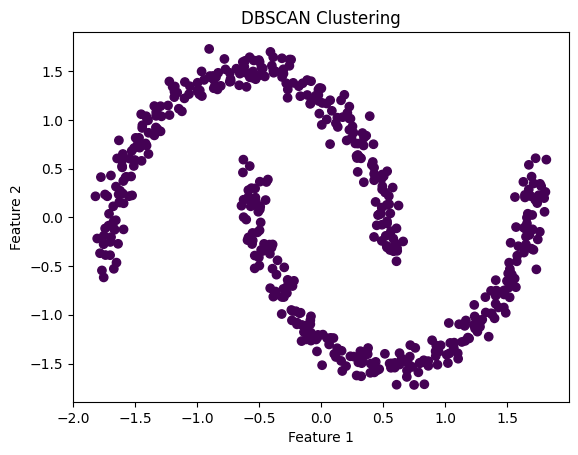

In [ ]:
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels_large

)
plt.xlabel("Feature 1")

plt.ylabel("Feature 2")

plt.title("DBSCAN Clustering")

plt.show()

In [ ]:
print("Small eps:", np.unique(labels_small, return_counts=True))

print("Normal eps:", np.unique(dbscan_labels, return_counts=True))

print("Large eps:", np.unique(labels_large, return_counts=True))

Small eps: (array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]), array([ 48, 118, 105,  21,  44,  17,  15,  19,  23,  19,   6,   5,  12,
        18,  15,  15]))
Normal eps: (array([0, 1]), array([250, 250]))
Large eps: (array([0, 1]), array([250, 250]))


Small eps → stricter neighbourhood → more noise/fragmentation.
Larger eps → more points connect → clusters become larger and may eventually merge.

eps too small
- many observations don't have enough neighbours
- lots of noise / fragmented clusters

appropriate eps
- dense moon shapes detected
- meaningful clusters

eps too large
- separate dense regions can connect
- clusters may merge